# Multilingual Analysis — Language Efficiency
This notebook is written as a short, publication-style narrative. It analyzes `experiments/experiments_output/multi_lingual_*` runs and compares how attribution behaves across languages.

If you want to analyze a different run, change `RUN` in the next code cell.

## 1. Hypothesis
Attribution should be *less concentrated* (higher entropy, lower top-1 mass fraction) when prompts are harder for the model in a given language, because uncertainty spreads credit across more tokens.

If the model is equally competent across languages, entropy and attention density should look similar for EN/ES/FR (after controlling for case).

## 2. The Experiment
We load the saved per-sample results, extract explainable units (text tokens / audio segments), and compute:
- **Shapley Entropy**: entropy of normalized $|SV|$ distribution (higher = more diffuse attribution).
- **Attention Density**: mean $|SV|$ per unit (higher = more mass per token/segment).
- **Top-1 mass fraction** and **effective tokens** (baseline concentration/spread metrics).

In [ ]:
import os
from itertools import chain

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_common import attention_density, shap_concentration_metrics, shapley_entropy
from IPython.display import display
from multilingual import DEFAULT_RUN, build_units_df

sns.set_style("whitegrid")
os.makedirs("figures", exist_ok=True)

# Pick the run folder under `experiments/experiments_output/`
RUN = DEFAULT_RUN

cases = ["T2T", "SM2T", "SF2T"]
units_df = pd.concat([build_units_df(c, run=RUN) for c in cases], ignore_index=True)

# Collapse possible multiple text messages per sample into a single sample-level row per unit_type


def _concat_svs(items) -> np.ndarray:
    parts = [np.asarray(x, dtype=float) for x in items]
    return np.concatenate(parts) if parts else np.asarray([], dtype=float)


def _concat_tokens(items) -> list[str]:
    return list(chain.from_iterable(items))


sample_df = units_df.groupby(
    ["run", "case", "row_index", "unit_type", "language", "original_language"],
    dropna=False,
    as_index=False,
).agg(
    {
        "tokens": _concat_tokens,
        "sv": _concat_svs,
        "inputs": "first",
        "count_explainable_units": "sum",
        "runtime_sec": "first",
        "n_calls": "first",
        "neyman_steps": "first",
        "input_modality": "first",
        "output_modality": "first",
        "attr_summary": "first",
        "prompt_texts": "first",
    }
)

sample_df.head()

/home/mvishiu11/Desktop/AudioShap_WUT_Bachelor/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


,run,case,row_index,unit_type,language,original_language,tokens,sv,inputs,count_explainable_units,runtime_sec,n_calls,neyman_steps,input_modality,output_modality,attr_summary,prompt_texts
0,multi_lingual_2026_01_03,SF2T,0,audio,fr,es,"[Avez-vous, entendu, parler, du, NAME_2]","[0.4075641632080078, 0.0, 0.19845375418663025,...",Avez-vous entendu parler du NAME_2,5,11.330355,30,1,audio__female,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.00000...",[Avez-vous entendu parler du NAME_2 d'Amphibia ?]
1,multi_lingual_2026_01_03,SF2T,1,audio,en,en,"[Could, you, elaborate, on, the, concept, of, ...","[0.037120189517736435, 0.046701498329639435, 0...",Could you elaborate on the concept of a transf...,17,301.664055,626,2,audio__female,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 0.99999...",[Could you elaborate on the concept of a trans...
2,multi_lingual_2026_01_03,SF2T,2,audio,en,en,"[What, type, of, soil, is, best, for, Eugenia'...","[0.2888733744621277, 0.0, 0.06041020154953003,...",What type of soil is best for Eugenia's growth?,9,75.518742,152,2,audio__female,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.00000...",[What type of soil is best for Eugenia's growth?]
3,multi_lingual_2026_01_03,SF2T,3,audio,fr,es,"[dis-moi, une, phrase, de, Fray, Luis, de, León]","[0.10654991865158081, 0.18794740736484528, 0.0...",dis-moi une phrase de Fray Luis de León,8,61.060631,118,2,audio__female,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.0, 'f...",[dis-moi une phrase de Fray Luis de León]
4,multi_lingual_2026_01_03,SF2T,4,audio,en,es,"[Main, HTML, meta, tags, organized, in, a, det...","[0.14529278874397278, 0.14312365651130676, 0.1...",Main HTML meta tags organized in a detailed list,9,63.124433,154,2,audio__female,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.00000...",[Main HTML meta tags organized in a detailed l...


count_explainable_units                                        \
                                 count       mean       std  min   25%   50%   
case unit_type                                                                 
SF2T audio                       108.0   9.879630  3.199642  5.0   8.0   9.0   
SM2T audio                       108.0   9.879630  3.199642  5.0   8.0   9.0   
T2T  text                        108.0  16.111111  4.838192  8.0  13.0  15.0   

                           runtime_sec              ...              \
                 75%   max       count        mean  ...         75%   
case unit_type                                      ...               
SF2T audio      11.0  20.0       108.0  109.266517  ...  136.272905   
SM2T audio      11.0  20.0       108.0  108.027026  ...  135.214561   
T2T  text       19.0  34.0       108.0  193.482635  ...  240.453869   

                           n_calls                                        \
                       max   count        mean         std    min    25%   
case unit_type                                                             
SF2T audio      376.700921   108.0  251.833333  173.782574   18.0  123.5   
SM2T audio      370.946383   108.0  251.814815  174.558784   18.0  122.0   
T2T  text       862.519189   108.0  624.481481  446.458368  122.0  347.5   

                                      
                  50%    75%     max  
case unit_type                        
SF2T audio      204.0  341.0   896.0  
SM2T audio      206.0  340.5   894.0  
T2T  text       477.0  794.5  2806.0  

[3 rows x 24 columns]

,n
language,
fr,108
en,108
es,108


language,en,es,fr
original_language,,,
en,36,36,36
es,36,36,36
fr,36,36,36


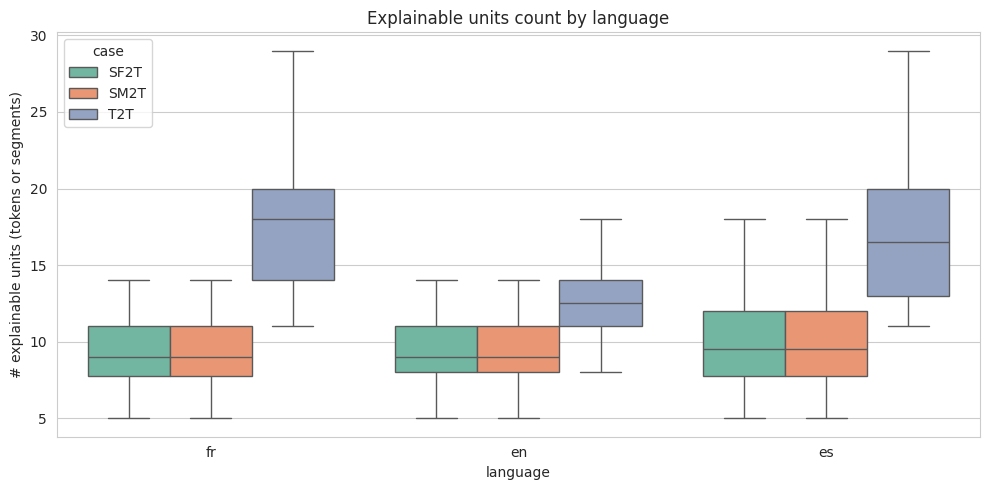

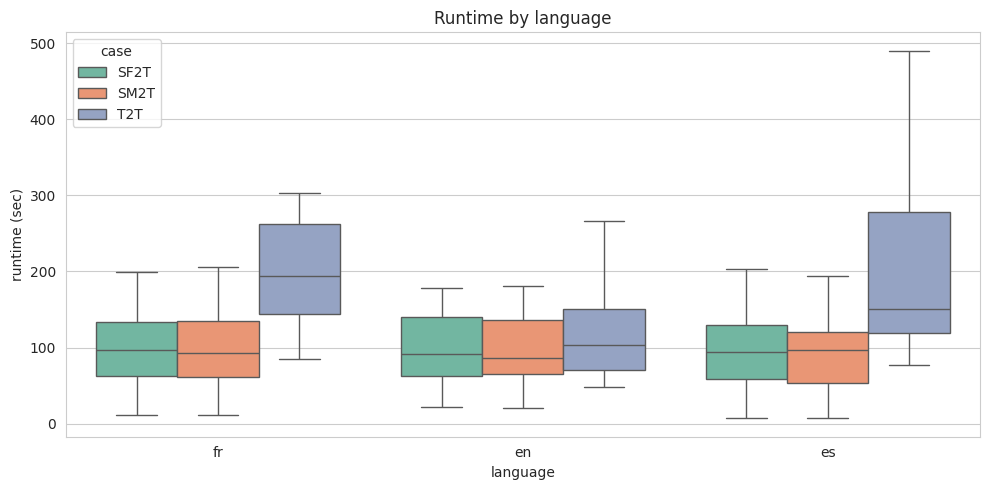

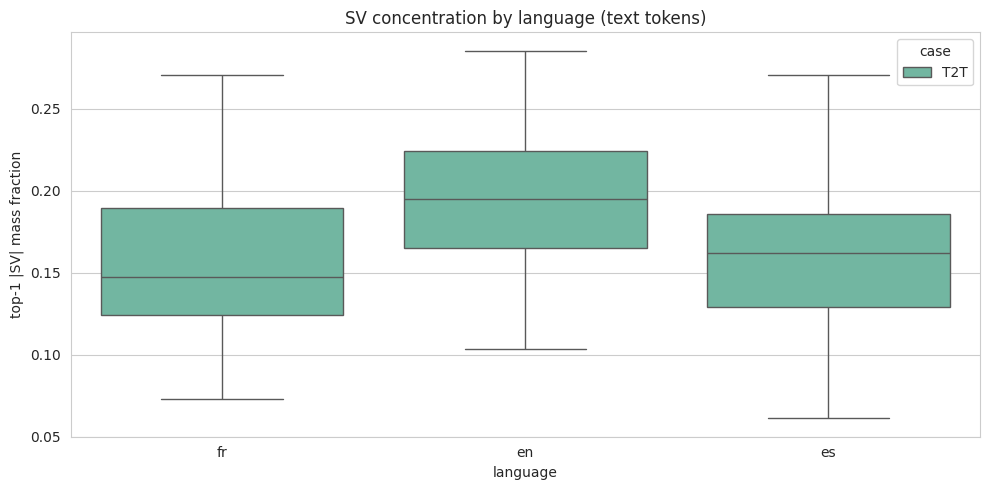

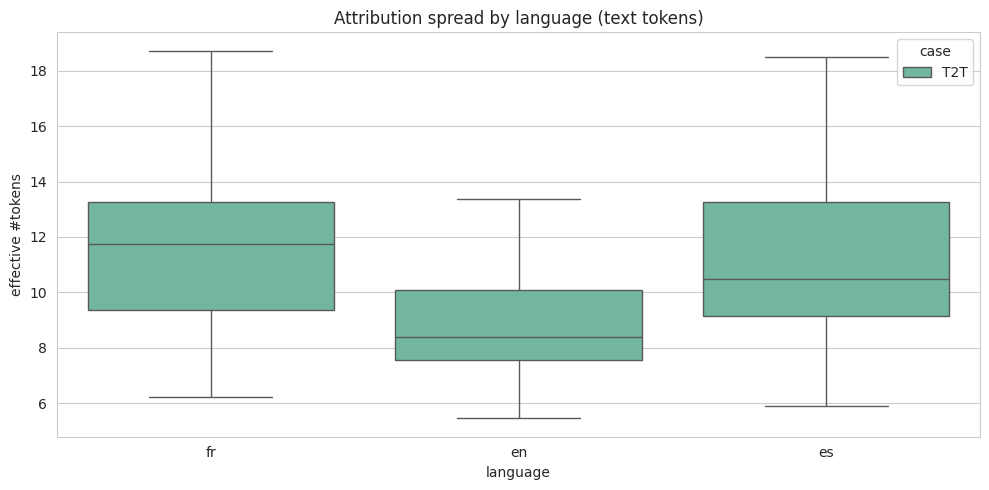

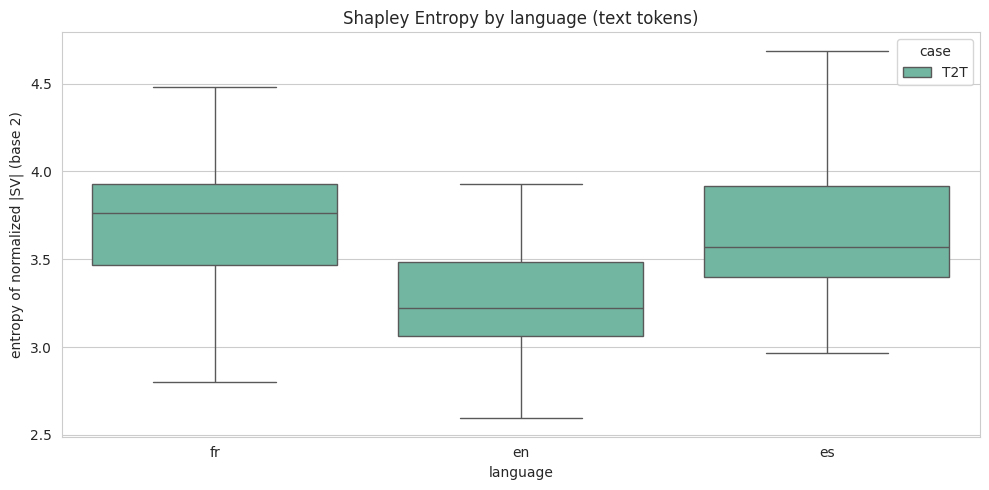

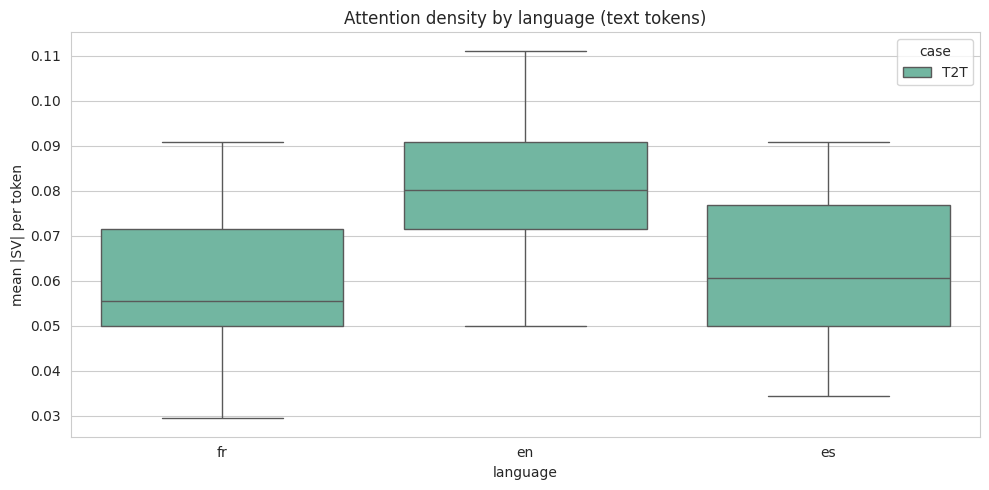

In [ ]:
# Basic sanity checks
if sample_df["count_explainable_units"].isna().any():
    raise RuntimeError("Missing explainable unit counts.")

# Add concentration metrics for each sample
metrics = sample_df["sv"].apply(shap_concentration_metrics).apply(pd.Series)
metrics.columns = [f"metric_{c}" for c in metrics.columns]

# Add requested narrative metrics
extra = pd.DataFrame(
    {
        "metric_entropy": sample_df["sv"].apply(shapley_entropy),
        "metric_attention_density": sample_df["sv"].apply(attention_density),
    }
)

sample_metrics_df = pd.concat([sample_df.drop(columns=["sv"]), metrics, extra], axis=1)

# Quick overview tables
display(
    sample_metrics_df.groupby(["case", "unit_type"])[["count_explainable_units", "runtime_sec", "n_calls"]].describe()
)

# Language distribution
display(sample_metrics_df["language"].value_counts(dropna=False).to_frame("n"))
display(pd.crosstab(sample_metrics_df["original_language"], sample_metrics_df["language"], dropna=False))

# 1) Count of explainable units by language
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sample_metrics_df,
    x="language",
    y="count_explainable_units",
    hue="case",
    palette="Set2",
    showfliers=False,
)
plt.title("Explainable units count by language")
plt.ylabel("# explainable units (tokens or segments)")
plt.tight_layout()
plt.savefig("figures/multi_lingual_count_units_by_language.png")
plt.show()

# 2) Runtime by case and language
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sample_metrics_df,
    x="language",
    y="runtime_sec",
    hue="case",
    palette="Set2",
    showfliers=False,
)
plt.title("Runtime by language")
plt.ylabel("runtime (sec)")
plt.tight_layout()
plt.savefig("figures/multi_lingual_runtime_by_language.png")
plt.show()

# 3) SV concentration (top-1 fraction of |SV| mass)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sample_metrics_df[sample_metrics_df["unit_type"] == "text"],
    x="language",
    y="metric_top1_frac",
    hue="case",
    palette="Set2",
    showfliers=False,
)
plt.title("SV concentration by language (text tokens)")
plt.ylabel("top-1 |SV| mass fraction")
plt.tight_layout()
plt.savefig("figures/multi_lingual_top1_frac_text_by_language.png")
plt.show()

# 4) Effective number of tokens (higher = more spread-out attribution)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sample_metrics_df[sample_metrics_df["unit_type"] == "text"],
    x="language",
    y="metric_effective_tokens",
    hue="case",
    palette="Set2",
    showfliers=False,
)
plt.title("Attribution spread by language (text tokens)")
plt.ylabel("effective #tokens")
plt.tight_layout()
plt.savefig("figures/multi_lingual_effective_tokens_text_by_language.png")
plt.show()

# 5) Shapley Entropy across languages (text tokens)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sample_metrics_df[sample_metrics_df["unit_type"] == "text"],
    x="language",
    y="metric_entropy",
    hue="case",
    palette="Set2",
    showfliers=False,
)
plt.title("Shapley Entropy by language (text tokens)")
plt.ylabel("entropy of normalized |SV| (base 2)")
plt.tight_layout()
plt.savefig("figures/multi_lingual_entropy_text_by_language.png")
plt.show()

# 6) Attention density across languages (text tokens)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sample_metrics_df[sample_metrics_df["unit_type"] == "text"],
    x="language",
    y="metric_attention_density",
    hue="case",
    palette="Set2",
    showfliers=False,
)
plt.title("Attention density by language (text tokens)")
plt.ylabel("mean |SV| per token")
plt.tight_layout()
plt.savefig("figures/multi_lingual_attention_density_text_by_language.png")
plt.show()

## 3. The Verdict
We summarize the effect sizes using medians per language (text tokens) and print an auto-verdict based on which language shows the highest entropy and which shows the highest attention density.

In [3]:
verdict_df = sample_metrics_df[sample_metrics_df["unit_type"] == "text"].copy()

summary = (
    verdict_df.groupby("language")
    .agg(
        median_entropy=("metric_entropy", "median"),
        median_attention_density=("metric_attention_density", "median"),
        median_top1=("metric_top1_frac", "median"),
        n=("row_index", "size"),
    )
    .sort_index()
)
display(summary)

if not summary.empty:
    lang_entropy_max = summary["median_entropy"].idxmax()
    lang_entropy_min = summary["median_entropy"].idxmin()
    lang_density_max = summary["median_attention_density"].idxmax()
    lang_density_min = summary["median_attention_density"].idxmin()

    print("Interpretation:")
    print(f"- Highest entropy (most diffuse attribution): {lang_entropy_max}")
    print(f"- Lowest entropy (most concentrated attribution): {lang_entropy_min}")
    print(f"- Highest attention density (most mass per token): {lang_density_max}")
    print(f"- Lowest attention density (least mass per token): {lang_density_min}")

    print("\nAuto-verdict:")
    if lang_entropy_max != lang_entropy_min:
        print(
            "Attribution is not language-invariant: entropy differs by language, "
            f"with {lang_entropy_max} most diffuse and {lang_entropy_min} most concentrated."
        )
    else:
        print("Entropy appears similar across languages in the median.")

    if lang_density_max != lang_density_min:
        print(
            "Attention density differs by language, " f"highest in {lang_density_max} and lowest in {lang_density_min}."
        )

,median_entropy,median_attention_density,median_top1,n
language,,,,
en,3.223692,0.080128,0.194790,36
es,3.568294,0.060662,0.162228,36
fr,3.764834,0.055556,0.147505,36


Interpretation:
- Highest entropy (most diffuse attribution): fr
- Lowest entropy (most concentrated attribution): en
- Highest attention density (most mass per token): en
- Lowest attention density (least mass per token): fr

Auto-verdict:
Attribution is not language-invariant: entropy differs by language, with fr most diffuse and en most concentrated.
Attention density differs by language, highest in en and lowest in fr.


## Micro-analysis: POS Breakdown
We test whether attribution concentrates on **content words** (NOUN/VERB/ADJ) vs **function words** (DET) differently across languages.

This section uses a best-effort POS assignment:
- If language-specific spaCy models are installed, it uses proper POS tags.
- Otherwise it falls back to a lightweight heuristic (reliable for DET/PUNCT; coarse for NOUN/VERB/ADJ).

,pos,language,mean_abs_sv,n
4,Noun,ES,0.061728,250
5,Noun,FR,0.064085,214
8,Verb,ES,0.054702,106
9,Verb,FR,0.052380,140
0,Adj,ES,0.045331,78
1,Adj,FR,0.042673,57
2,Det,ES,0.050283,56
3,Det,FR,0.045225,70
6,Punct,ES,0.065727,21
7,Punct,FR,0.031049,23


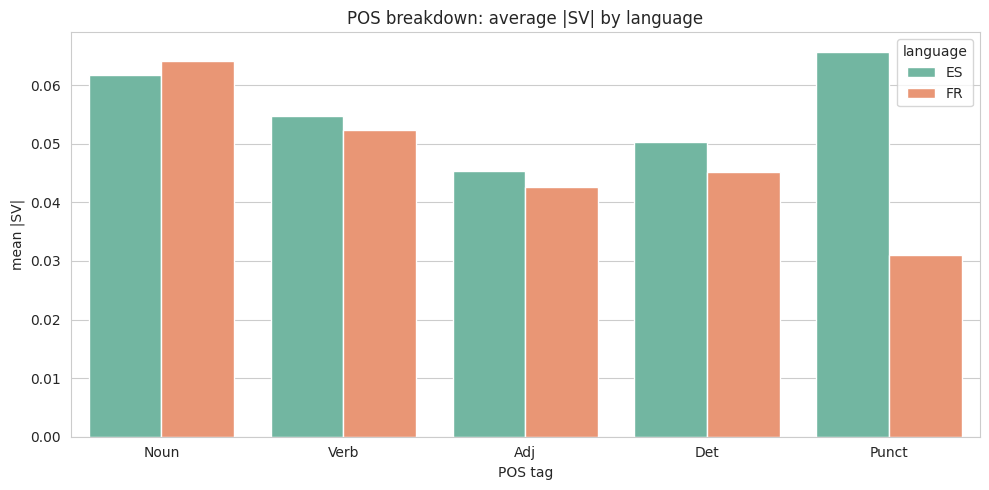

In [ ]:
from multilingual import compute_pos_breakdown

pos_summary = compute_pos_breakdown(sample_df)
display(pos_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=pos_summary, x="pos", y="mean_abs_sv", hue="language", palette="Set2")
plt.title("POS breakdown: average |SV| by language")
plt.xlabel("POS tag")
plt.ylabel("mean |SV|")
plt.tight_layout()
plt.savefig("figures/multi_lingual_pos_breakdown_mean_abs_sv.png")
plt.show()

In [6]:
# Token-level view for TEXT units only
exploded = sample_df[sample_df["unit_type"] == "text"].copy()
exploded = exploded.explode(["tokens", "sv"]).rename(columns={"tokens": "token", "sv": "sv"})
exploded["sv"] = exploded["sv"].astype(float)
exploded["abs_sv"] = exploded["sv"].abs()
exploded = exploded.reset_index(drop=True)

# Top tokens by mean |SV| per language (quick qualitative check)
top_tokens = (
    exploded.groupby(["language", "token"])
    .agg(mean_abs_sv=("abs_sv", "mean"), n=("abs_sv", "size"))
    .reset_index()
    .sort_values(["language", "mean_abs_sv"], ascending=[True, False])
)
display(top_tokens.groupby("language").head(20))

,language,token,mean_abs_sv,n
232,en,Unfortunately,0.285275,1
215,en,Hi,0.258446,1
227,en,Te,0.240405,1
276,en,reet,0.234158,1
146,en,practicing,0.223952,1
274,en,pose,0.223218,1
163,en,soil,0.219032,1
230,en,Today,0.215026,2
226,en,Spring,0.206204,1
15,en,HTML,0.203942,1
